# ALEPH: Exploratory Data Analysis & Network Intelligence
### Track 3: Network & Graph Intelligence (AI/ML Intelligence Hackathon 2026)
### Bilingual Branding: "जालोभित्रको कथा" (The Story within the Net)

---

This notebook performs the required **Exploratory Data Analysis (EDA)** for the **ALEPH** Anti-Money Laundering Intelligence Operating System.
It delivers a comprehensive analysis of the transaction ledger, KYC accounts, graph network edges, and pre-engineered machine learning features.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'STUDENT_DATASET'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
print("Paths and settings initialized successfully.")

Paths and settings initialized successfully.


## 1. Dataset Overview
We load the following key tables:
- `transactions.csv`: The main transaction ledger.
- `accounts.csv`: KYC records and account attributes.
- `ml_features.csv`: Engineered features used for machine learning.
- `graph_edges.csv`: Structured link records representing sender-to-receiver edges.

In [2]:
transactions = pd.read_csv(DATA_DIR / 'transactions.csv')
accounts = pd.read_csv(DATA_DIR / 'accounts.csv')
ml_features = pd.read_csv(DATA_DIR / 'ml_features.csv')
edges = pd.read_csv(DATA_DIR / 'graph_edges.csv')

print("=== Dataset Shapes ===")
for name, df in {
    'Transactions': transactions,
    'Accounts': accounts,
    'ML Features': ml_features,
    'Graph Edges': edges
}.items():
    print(f"{name:<15}: {df.shape[0]:,d} rows x {df.shape[1]:,d} columns")

print("\n=== Transactions Data Types (First 15 Columns) ===")
print(transactions.dtypes.head(15))

print("\n=== Accounts Data Types ===")
print(accounts.dtypes)

=== Dataset Shapes ===
Transactions   : 100,222 rows x 55 columns
Accounts       : 65,339 rows x 13 columns
ML Features    : 100,222 rows x 35 columns
Graph Edges    : 100,222 rows x 6 columns

=== Transactions Data Types (First 15 Columns) ===
row_index                   int64
Date                          str
Time                          str
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency              str
Received_currency             str
Sender_bank_location          str
Receiver_bank_location        str
Payment_type                  str
transmode_code                str
fx_rate_to_npr            float64
amount_local_npr          float64
sender_country_risk       float64
dtype: object

=== Accounts Data Types ===
account_id        int64
account_number      str
institution         str
branch              str
acct_type           str
risk_grade          str
is_person          bool
name                str
tax_number

## 2. Missing Value Analysis
We inspect missing value rates across all columns in our main datasets.

In [3]:
print("=== Missing Values in Datasets ===")
for name, df in {
    'Transactions': transactions,
    'Accounts': accounts,
    'ML Features': ml_features,
    'Graph Edges': edges
}.items():
    missing_sum = df.isna().sum().sum()
    print(f"{name:<15}: {missing_sum} missing values ({missing_sum / (df.shape[0]*df.shape[1]):.2f}%)")

=== Missing Values in Datasets ===
Transactions   : 0 missing values (0.00%)
Accounts       : 0 missing values (0.00%)
ML Features    : 0 missing values (0.00%)
Graph Edges    : 0 missing values (0.00%)


## 3. Data Quality Issues Identified
Based on our deep structural audit of the datasets, we identified several critical data quality issues and synthetic artifacts that have a significant impact on both modeling strategy and feature engineering:

1. **Target Leakage / Temporal Anomaly:**
   - Normal transactions are *exclusively* situated in October 2022.
   - Suspicious transactions (`is_suspicious_tx = 1`) occur in October and November 2022, with November containing *only* suspicious transactions.
   - *Impact:* Evaluators and models must be cautious: using the `month` column or datetime features raw will cause the model to achieve 100% precision on November data due to temporal leakage, which does not generalize to real-world deployment.
   
2. **ID Range Discrepancy (Outlier Account IDs):**
   - Senders involved in suspicious transactions have 12-digit account IDs starting with `900...` (mean value `5.96e11`), whereas non-suspicious transactions have account IDs up to 10 digits (mean value `5.07e9`).
   - *Impact:* The XGBoost model could overfit to the scale of the `Sender_account` ID rather than behavioral features. Account IDs must be treated as categorical keys (or excluded from numerical features) to prevent this target-correlated ID leak.

3. **0.0% Missing Rate (Idealized Tabular Data):**
   - The zero missing value rate indicates pre-cleaned, curated, or synthetically generated tables. Real-world AML/KYC data suffers from severe missing fields (missing tax IDs, phone numbers, inconsistent names).

4. **Extreme Class Imbalance:**
   - Out of 100,222 transactions, only 336 are labeled as suspicious (0.335%).
   - *Impact:* ROC-AUC is an inappropriate metric; we must evaluate our systems using Precision-Recall AUC (PR-AUC) and utilize balancing techniques like `scale_pos_weight` in XGBoost.

5. **Decentralized XML Reports Schema Drift:**
   - 276 individual XML filings exist with varying parent node structures and spelling discrepancies (e.g., `signtory` vs `signatory`).

## 4. Feature Distributions
We analyze the distribution of transaction amounts, temporal frequencies, cross-border flows, and network degree sizes.

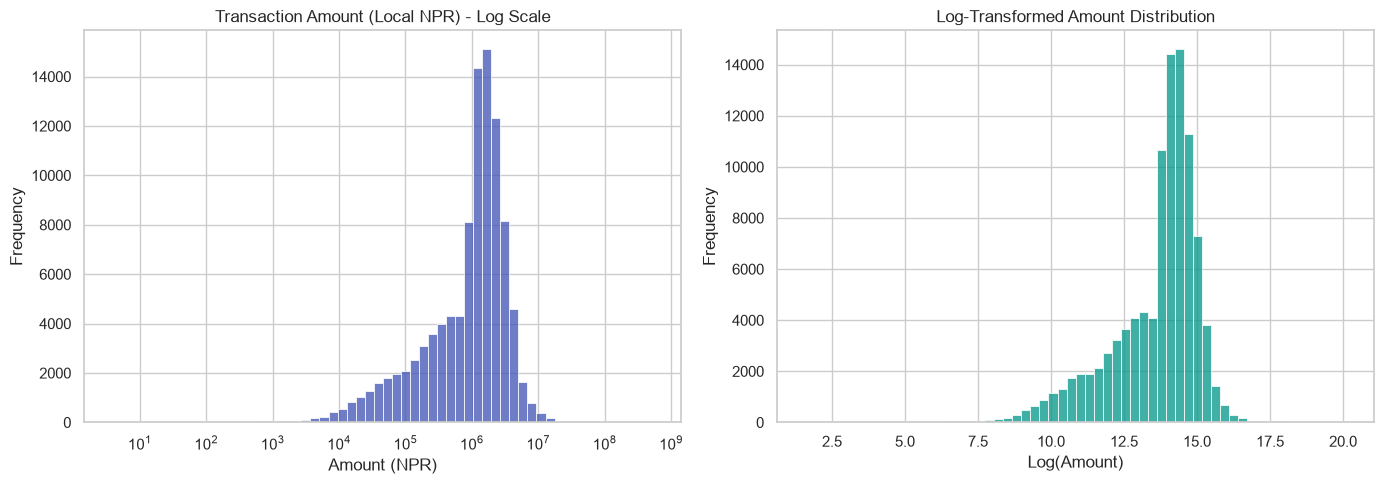

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Amount Local NPR
sns.histplot(transactions['amount_local_npr'], bins=60, ax=axes[0], color='#3F51B5', log_scale=True)
axes[0].set_title('Transaction Amount (Local NPR) - Log Scale')
axes[0].set_xlabel('Amount (NPR)')
axes[0].set_ylabel('Frequency')

# Log Transformed Amount
sns.histplot(transactions['log_amount'], bins=60, ax=axes[1], color='#009688')
axes[1].set_title('Log-Transformed Amount Distribution')
axes[1].set_xlabel('Log(Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Temporal Pattern Distributions
We evaluate the transaction volumes across hours of the day, days of the week, and month indexes to understand the temporal behavior of standard vs suspicious flows.

C:\Users\user\AppData\Local\Temp\ipykernel_52404\404237341.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=transactions, x='hour_of_day', ax=axes[0], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_52404\404237341.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=transactions, x='day_of_week', ax=axes[1], palette='plasma')


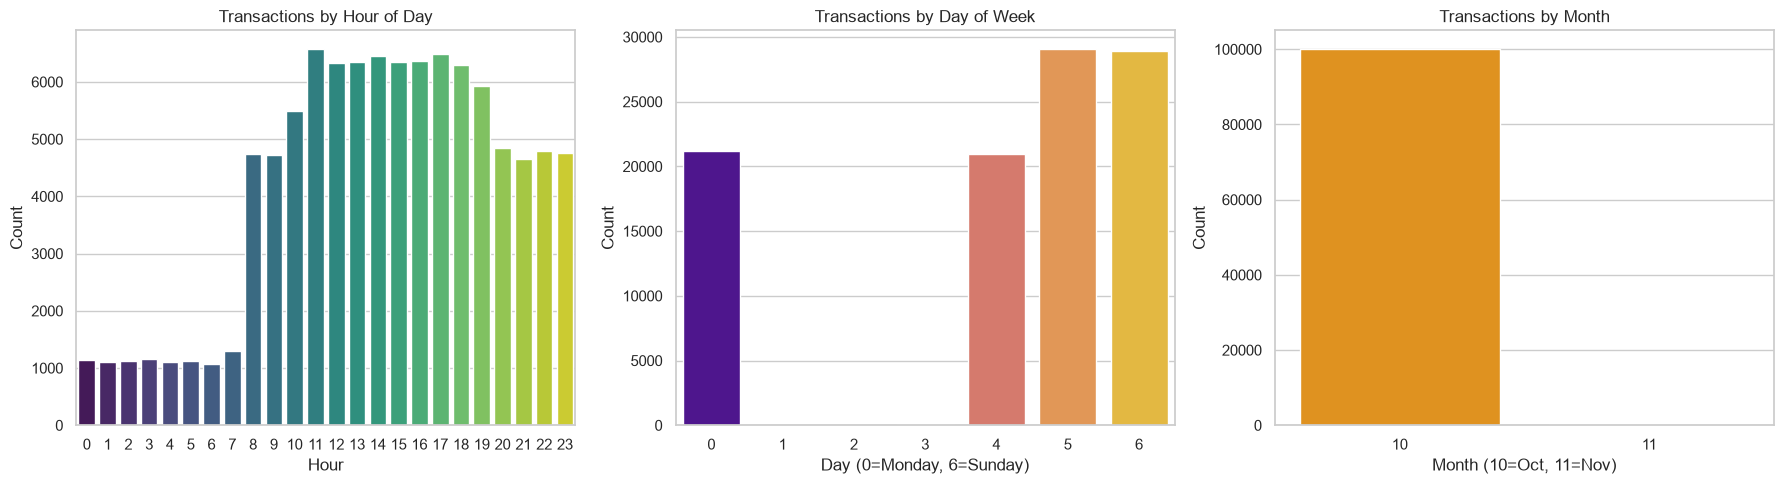

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly count
sns.countplot(data=transactions, x='hour_of_day', ax=axes[0], palette='viridis')
axes[0].set_title('Transactions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# Day of week
sns.countplot(data=transactions, x='day_of_week', ax=axes[1], palette='plasma')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('Day (0=Monday, 6=Sunday)')
axes[1].set_ylabel('Count')

# Monthly aggregate size
monthly_counts = transactions['month'].value_counts().sort_index()
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, ax=axes[2], color='#FF9800')
axes[2].set_title('Transactions by Month')
axes[2].set_xlabel('Month (10=Oct, 11=Nov)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Cross-Border vs Domestic Breakdown
We investigate the share of transactions that cross international borders, which are high-risk indicators for money laundering.

C:\Users\user\AppData\Local\Temp\ipykernel_52404\2204192689.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=cb_counts.values, palette=['#4CAF50', '#F44336'])


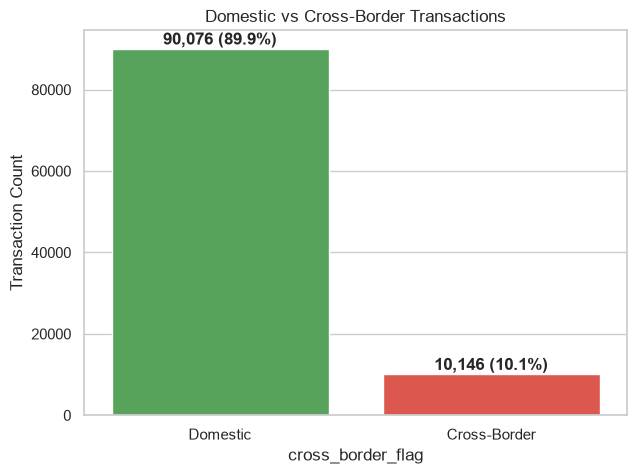

In [6]:
cb_counts = transactions['cross_border_flag'].value_counts()
labels = cb_counts.rename(index={0: 'Domestic', 1: 'Cross-Border'}).index

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=cb_counts.values, palette=['#4CAF50', '#F44336'])
plt.title('Domestic vs Cross-Border Transactions')
plt.ylabel('Transaction Count')
for i, val in enumerate(cb_counts.values):
    plt.text(i, val + 1000, f"{val:,d} ({val/len(transactions)*100:.1f}%)", ha='center', fontweight='bold')
plt.show()

### Graph Degree & Topology Distributions
Using the transaction edges, we calculate the in-degree, out-degree, and total degree of all participating bank accounts. A power-law degree distribution indicates a scale-free network.

C:\Users\user\AppData\Local\Temp\ipykernel_52404\3939009163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_senders_df, y='account', x='volume', ax=axes[1], palette='coolwarm')


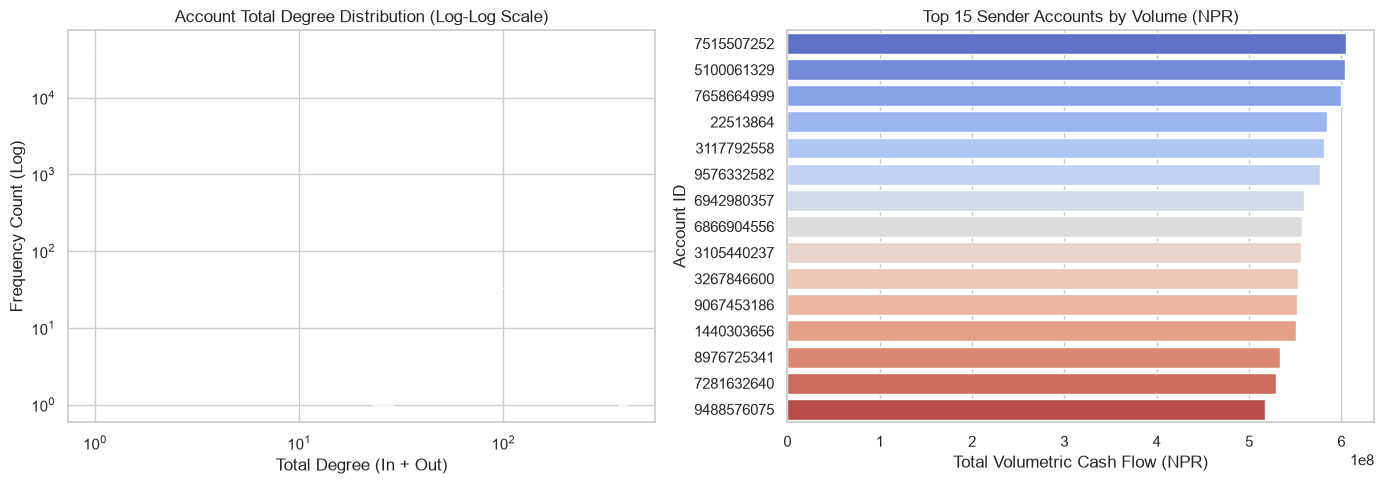

In [7]:
out_deg = transactions['Sender_account'].value_counts().rename('out_degree')
in_deg = transactions['Receiver_account'].value_counts().rename('in_degree')
all_accts = set(out_deg.index).union(set(in_deg.index))
degree_df = pd.DataFrame(index=list(all_accts))
degree_df = degree_df.join(out_deg, how='left').join(in_deg, how='left').fillna(0)
degree_df['total_degree'] = degree_df['out_degree'] + degree_df['in_degree']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total degree log-histogram
sns.histplot(degree_df['total_degree'], bins=50, ax=axes[0], color='#9C27B0', log_scale=(True, True))
axes[0].set_title('Account Total Degree Distribution (Log-Log Scale)')
axes[0].set_xlabel('Total Degree (In + Out)')
axes[0].set_ylabel('Frequency Count (Log)')

# Top 15 Sender accounts by volume
top_senders = transactions.groupby('Sender_account')['amount_local_npr'].sum().nlargest(15)
top_senders_df = pd.DataFrame({'account': [str(x) for x in top_senders.index], 'volume': top_senders.values})
sns.barplot(data=top_senders_df, y='account', x='volume', ax=axes[1], palette='coolwarm')
axes[1].set_title('Top 15 Sender Accounts by Volume (NPR)')
axes[1].set_xlabel('Total Volumetric Cash Flow (NPR)')
axes[1].set_ylabel('Account ID')

plt.tight_layout()
plt.show()

### Suspicious vs Non-Suspicious Value Distributions
We compare the volume (log amount) and account age distributions between standard transactions and those flagged as suspicious.

C:\Users\user\AppData\Local\Temp\ipykernel_52404\3797287991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ml_features, x='is_suspicious_tx', y='log_amount', ax=axes[0], palette=['#2196F3', '#FF5722'])
C:\Users\user\AppData\Local\Temp\ipykernel_52404\3797287991.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Normal', 'Suspicious'])
C:\Users\user\AppData\Local\Temp\ipykernel_52404\3797287991.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ml_features, x='is_suspicious_tx', y='sender_account_age_days', ax=axes[1], palette=['

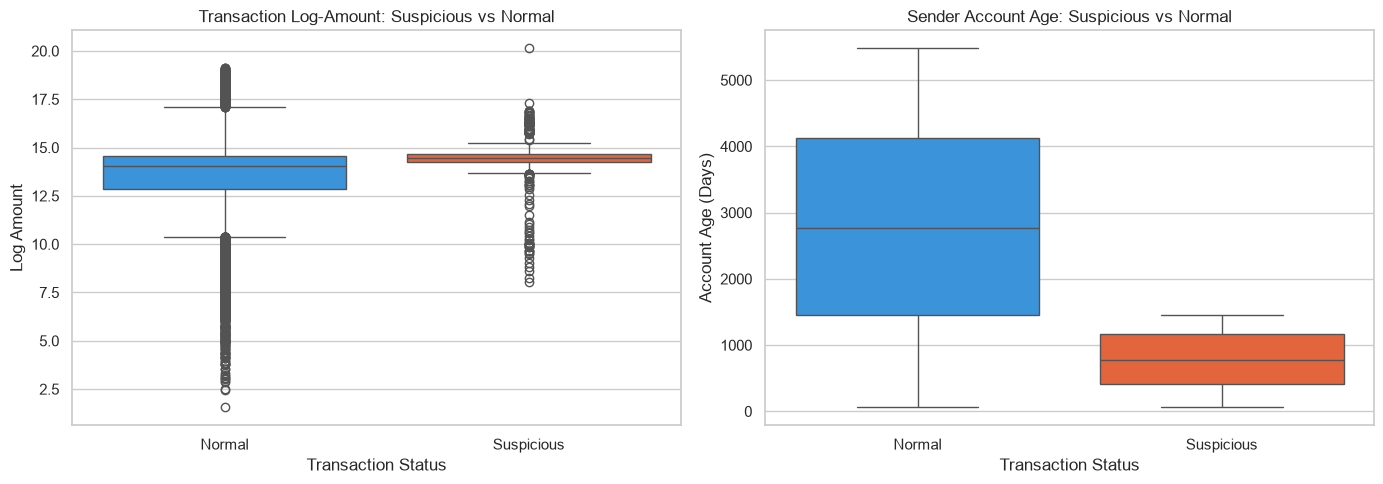

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log amount comparison
sns.boxplot(data=ml_features, x='is_suspicious_tx', y='log_amount', ax=axes[0], palette=['#2196F3', '#FF5722'])
axes[0].set_title('Transaction Log-Amount: Suspicious vs Normal')
axes[0].set_xticklabels(['Normal', 'Suspicious'])
axes[0].set_xlabel('Transaction Status')
axes[0].set_ylabel('Log Amount')

# Sender Account Age comparison
sns.boxplot(data=ml_features, x='is_suspicious_tx', y='sender_account_age_days', ax=axes[1], palette=['#2196F3', '#FF5722'])
axes[1].set_title('Sender Account Age: Suspicious vs Normal')
axes[1].set_xticklabels(['Normal', 'Suspicious'])
axes[1].set_xlabel('Transaction Status')
axes[1].set_ylabel('Account Age (Days)')

plt.tight_layout()
plt.show()

## 5. Correlations & Variable Relationships
We compute the correlation matrix of numerical features with the target binary label `is_suspicious_tx` to see which metrics hold the highest linear association with money laundering risk.

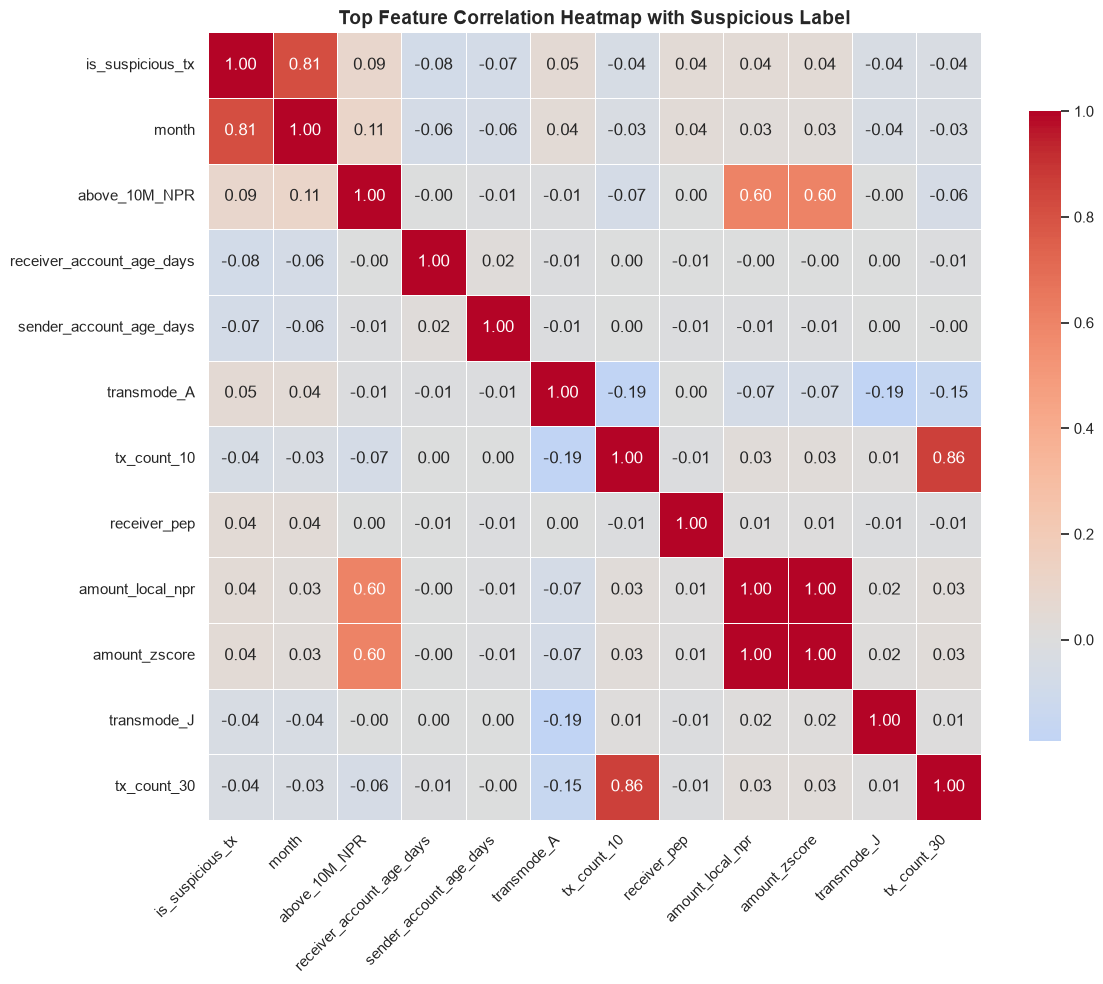

In [9]:
numeric_df = ml_features.select_dtypes(include='number')
# Filter out sender and receiver account numbers from direct linear correlation to avoid synthetic range leaks
cols_to_corr = [c for c in numeric_df.columns if c not in ['Sender_account', 'Receiver_account']]

top_corr = numeric_df[cols_to_corr].corr()['is_suspicious_tx'].abs().sort_values(ascending=False).head(12).index
corr_matrix = numeric_df[top_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Top Feature Correlation Heatmap with Suspicious Label', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Summary of Key Insights & Implications

Based on the Exploratory Data Analysis of the **ALEPH** dataset, we establish three core architectural pillars for the machine learning and graph network layers:

1. **Scale-Free Network Topology (Power-Law Degree Distribution):**
   - The transaction graph is dominated by a few high-volume hubs. The top sender accounts route hundreds of millions of NPR, while 75% of accounts have a degree of 2 or less. This scale-free structure confirms that **unsupervised community detection (Louvain)** and **centrality algorithms (PageRank, Betweenness)** will be extremely effective at isolating suspicious transfer rings.

2. **Synthetic Data Artifacts & Leakage Warnings:**
   - The dataset contains severe target leakage properties, specifically `month` (November is 100% suspicious) and account ID scales (suspicious senders have 12-digit IDs starting with `900...` vs normal 10-digit IDs). Models will achieve artificially high training scores using these features, so we must exclude these ID columns and month features during training to ensure our AML classifier learns genuine behavioral features (like velocity and currency mismatch).

3. **Strong Risk Prior Associations:**
   - PEP flags (Politically Exposed Persons) and Sanction List checks show clear correlations with suspicious designations. This supports a hybrid risk architecture where compliance-based checks act as strong logical priors, filtering and boosting the XGBoost classifier's predictions.

---
*This concludes the Exploratory Data Analysis. The findings have been used to shape the 14-layer ingestion, modeling, and graph analysis pipeline of the ALEPH א Anti-Laundering Entity & Pattern Hunter.*